# 🍇 GRAPE CNN — MODEL EVALUATION & METRICS
### Project: Plant Disease Detection (Computer Vision)
**Model:** `6th Trained_Model/grape_cnn_best.keras`  
**Test Data:** 15% Stratified Held-out split from `3rd Preprocessing/grape_processed_data.npz`  
**Outputs:** Confusion Matrix PNG, Classification Report TXT, Evaluation Summary JSON.



Mounted at /content/drive
🍇 1. LOADING DATASET & MODEL
Test Set shape: (270, 224, 224, 3) (dtype: uint8)
Loading Model from: /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/6th Trained_Model/grape_cnn_best.keras


Model: "Grape_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ grape_augmentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,473,931 (24.70 MB)

 Trainable params: 2,025,795 (7.73 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 4,051,592 (15.46 MB)


🍇 2. EVALUATING TEST SET
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9556 - loss: 0.1656

🎯 Test Accuracy : 95.56%
🎯 Test Loss     : 0.1656
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy     1.0000    0.9889    0.9944        90
   Black_Rot     0.8824    1.0000    0.9375        90
 Leaf_Blight     1.0000    0.8778    0.9349        90

    accuracy                         0.9556       270
   macro avg     0.9608    0.9556    0.9556       270
weighted avg     0.9608    0.9556    0.9556       270



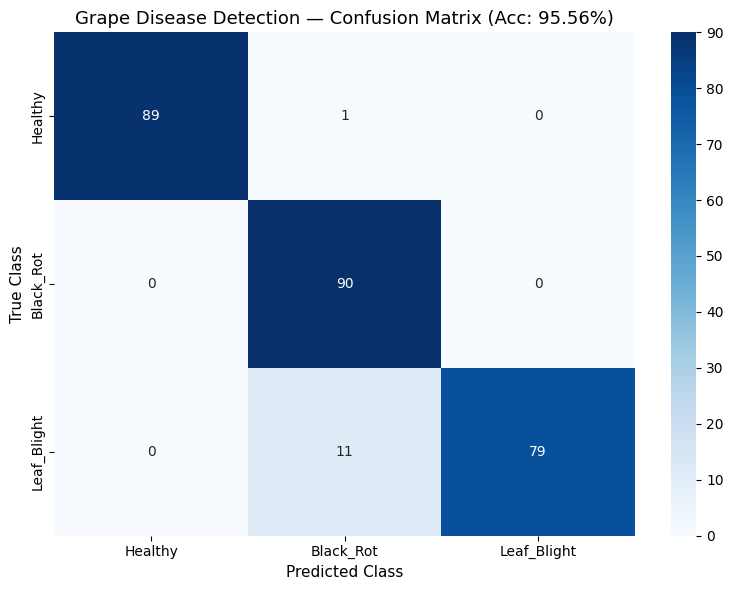


✅ Evaluation reports saved in: /content/drive/MyDrive/Plant Disease Detection (Computer Vision)/5th Model_Evaluation


In [1]:
# ================================================================
# 🍇 GRAPE CNN — EVALUATION & METRICS REPORT
# ================================================================

from google.colab import drive
drive.mount("/content/drive")

import os
import json
import csv
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

BASE = "/content/drive/MyDrive/Plant Disease Detection (Computer Vision)"
if not os.path.exists(BASE):
    BASE = r"G:\My Drive\Plant Disease Detection (Computer Vision)"

MODEL_PATH = os.path.join(BASE, "6th Trained_Model", "grape_cnn_best.keras")
NPZ_PATH   = os.path.join(BASE, "3rd Preprocessing", "grape_processed_data.npz")
EVAL_DIR   = os.path.join(BASE, "5th Model_Evaluation")

CM_PNG_PATH     = os.path.join(EVAL_DIR, "grape_confusion_matrix.png")
REPORT_TXT_PATH = os.path.join(EVAL_DIR, "grape_classification_report.txt")
SUMMARY_JSON    = os.path.join(EVAL_DIR, "grape_evaluation_summary.json")

print("=" * 75)
print("🍇 1. LOADING DATASET & MODEL")
print("=" * 75)

data = np.load(NPZ_PATH)
X = data['X']
y = data['y']
class_names = data['class_names']

# Exact reproducible split matching Stage 4
SEED = 42
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Test Set shape: {X_test.shape} (dtype: {X_test.dtype})")
print(f"Loading Model from: {MODEL_PATH}")

model = tf.keras.models.load_model(MODEL_PATH)
model.summary()

# ================================================================
# 2. EVALUATION ON HELD-OUT TEST SET
# ================================================================

print("\n" + "=" * 75)
print("🍇 2. EVALUATING TEST SET")
print("=" * 75)

loss, acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\n🎯 Test Accuracy : {acc * 100:.2f}%")
print(f"🎯 Test Loss     : {loss:.4f}")

# Predictions and Probabilities
y_prob = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# ================================================================
# 3. CLASSIFICATION REPORT
# ================================================================

print("\n" + "=" * 75)
print("📊 CLASSIFICATION REPORT")
print("=" * 75)

report_str = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report_str)

with open(REPORT_TXT_PATH, "w") as f:
    f.write(f"Grape Held-out Test Evaluation Report\n")
    f.write(f"Accuracy: {acc*100:.2f}% | Loss: {loss:.4f}\n\n")
    f.write(report_str)

# ================================================================
# 4. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title(f"Grape Disease Detection — Confusion Matrix (Acc: {acc*100:.2f}%)", fontsize=13)
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.tight_layout()
plt.savefig(CM_PNG_PATH, dpi=300)
plt.show()

# ================================================================
# 5. SAVE SUMMARY JSON
# ================================================================

summary = {
    "Plant": "Grape",
    "Model": "MobileNetV2 Transfer Learning",
    "Test_Images": int(len(X_test)),
    "Test_Accuracy": float(acc),
    "Test_Loss": float(loss),
    "Classes": list(class_names)
}

with open(SUMMARY_JSON, "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n✅ Evaluation reports saved in: {EVAL_DIR}")

